# Step 1: Import Essential Libraries

In [1]:
# Data Handling & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models (Example starting points)
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Step 2: Load Data

In [2]:
# Define the data path
DATA_PATH = "/kaggle/input/octwave-obesity-2"

# Load the datasets
train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')
submission_df = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')

# Phase 2: Exploratory Data Analysis (EDA) and Preprocessing 🔍
**Step 3: Initial Data Inspection**

In [3]:
# --- Step 3: Initial Data Inspection ---

print("--- 1. Training Data Shape ---")
print(f"Train set has {train_df.shape[0]} rows and {train_df.shape[1]} columns.\n")
print(f"Test set has {test_df.shape[0]} rows and {test_df.shape[1]} columns.\n")

print("--- 2. Training Data Head (First 5 Rows) ---")
print(train_df.head())
print("\n")

print("--- 3. Training Data Information (Data Types and Non-Null Counts) ---")
train_df.info()
print("\n")

print("--- 4. Numerical Feature Summary Statistics ---")
print(train_df.describe())
print("\n")

print("--- 5. Missing Values Check (Crucial for Preprocessing) ---")
# Count the number of null values for each column
missing_values = train_df.isnull().sum()
# Filter to show only columns with missing data
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("Columns with Missing Values in Train Set:")
    print(missing_values.sort_values(ascending=False))
else:
    print("No missing values found in the training set.")
print("\n")

print("--- 6. Categorical Feature Unique Values Check (Optional but helpful) ---")
# Check unique values for a few key categorical columns to spot inconsistencies
for col in ['Gender', 'Family_History', 'Commute_Mode', 'Physical_Activity_Level','High_Calorie_Food','Snack_Frequency','Smoking_Habit','Alcohol_Consumption','Leisure Time Activity']:
    if col in train_df.columns:
        print(f"Unique values in '{col}': {train_df[col].unique()}")

--- 1. Training Data Shape ---
Train set has 1995 rows and 20 columns.

Test set has 855 rows and 19 columns.

--- 2. Training Data Head (First 5 Rows) ---
  PersonID  Age_Years   Weight_Kg High_Calorie_Food  Vegetable_Intake  \
0    P1810  26.000000  109.959714               yes          3.000000   
1    P1021  25.483381   64.848627                no          2.000000   
2    P2036  26.000000  104.947703               yes          3.000000   
3    P2201  21.715198  107.868047               Yes          3.031308   
4    P2649  17.511767  121.460361               yes          1.964873   

   Meal_Frequency  Water_Intake  Screen_Time_Hours  Family_Risk  \
0        3.000000      2.679137           0.479348     1.000000   
1        1.000000      1.000000           0.000000     1.000000   
2        3.000000      2.577210           0.402075     1.000000   
3        3.322455      1.983531          -0.005858     0.987933   
4        1.052297      2.025586           0.981999     1.004136   

  

# Step 4: Data Cleaning and Standardization

**4a. Standardization and Typo Fixing**
Fix the inconsistent capitalization and typos in categorical features.

In [4]:
# --- 4a. Standardization and Typo Fixing ---

# List of columns to convert to lowercase for consistency
lower_cols = ['High_Calorie_Food', 'Family_History']

for df in [train_df, test_df]:
    # 1. Standardize capitalization
    for col in lower_cols:
        # Use .str.lower() to handle 'yes' vs 'Yes', etc.
        df[col] = df[col].astype(str).str.lower()
    
    # 2. Fix known typos
    # Fix 'yess' typo in Family_History
    df['Family_History'] = df['Family_History'].replace('yess', 'yes')

    # Fix 'Sport' vs 'Sports' in Leisure Time Activity
    df['Leisure Time Activity'] = df['Leisure Time Activity'].replace('Sport', 'Sports')



**4b. Missing Value Imputation**
You have three columns with missing values:

1. Physical_Activity_Level (1498 missing): Since such a large percentage is missing, imputing with a new category like 'Unknown' is the safest approach, as 'missing' likely represents a distinct group (e.g., data was not collected, or the person didn't fit the categories).

2. Gender (30 missing): A small number. Impute with the mode (most frequent value).

3. Alcohol_Consumption (37 missing): A small number. Impute with the mode.

In [5]:
# --- 4b. Missing Value Imputation ---

# 1. Impute Physical_Activity_Level with 'Unknown'
for df in [train_df, test_df]:
    df['Physical_Activity_Level'].fillna('Unknown', inplace=True)

# 2. Impute Gender and Alcohol_Consumption with the Mode from the TRAIN SET
# CRITICAL: Always derive imputation values (like the mode) from the TRAINING set only
gender_mode = train_df['Gender'].mode()[0]
alcohol_mode = train_df['Alcohol_Consumption'].mode()[0]

for df in [train_df, test_df]:
    df['Gender'].fillna(gender_mode, inplace=True)
    df['Alcohol_Consumption'].fillna(alcohol_mode, inplace=True)

print("Data cleaning and imputation complete.")

print("--- Missing Values Check ---")
# Count the number of null values for each column
missing_values = train_df.isnull().sum()
# Filter to show only columns with missing data
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("Columns with Missing Values in Train Set:")
    print(missing_values.sort_values(ascending=False))
else:
    print("No missing values found in the training set.")
print("\n")

text_cols = ['Gender', 'Family_History', 'Commute_Mode', 'Physical_Activity_Level','High_Calorie_Food','Snack_Frequency','Smoking_Habit','Alcohol_Consumption','Leisure Time Activity']

for df in [train_df, test_df]:
    # 1. Standardize capitalization
    for col in text_cols:
        # Use .str.lower() to handle 'yes' vs 'Yes', etc.
        df[col] = df[col].astype(str).str.lower()

print("--- Categorical Feature Unique Values Check ---")
# Check unique values for a few key categorical columns to spot inconsistencies
for col in text_cols:
    if col in train_df.columns:
        print(f"Unique values in '{col}': {train_df[col].unique()}")



Data cleaning and imputation complete.
--- Missing Values Check ---
No missing values found in the training set.


--- Categorical Feature Unique Values Check ---
Unique values in 'Gender': ['female' 'male']
Unique values in 'Family_History': ['yes' 'no']
Unique values in 'Commute_Mode': ['public_transportation' 'automobile' 'walking' 'motorbike' 'bike']
Unique values in 'Physical_Activity_Level': ['unknown' 'medium' 'low' 'high']
Unique values in 'High_Calorie_Food': ['yes' 'no']
Unique values in 'Snack_Frequency': ['occasionally' 'often' 'always' 'never']
Unique values in 'Smoking_Habit': ['no' 'yes']
Unique values in 'Alcohol_Consumption': ['sometimes' 'no' 'frequently' 'always']
Unique values in 'Leisure Time Activity': ['reading' 'gaming' 'music' 'painting' 'sports']


/tmp/ipykernel_18/4235193090.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Physical_Activity_Level'].fillna('Unknown', inplace=True)
/tmp/ipykernel_18/4235193090.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

# Step 5: Critical Feature Engineering (BMI) 

In [6]:
# --- Step 5: Critical Feature Engineering (BMI) ---

for df in [train_df, test_df]:
    # 1. Calculate BMI: Weight (kg) / (Height (m))^2
    df['BMI'] = df['Weight_Kg'] / (df['Height_cm'] / 100)**2
    
    # 2. Drop raw weight/height columns now that BMI is calculated
    # Also drop PersonID as it's not a feature
    df.drop(['Weight_Kg', 'Height_cm'], axis=1, inplace=True)

print("BMI feature calculated, and raw columns dropped for both train and test sets.")

BMI feature calculated, and raw columns dropped for both train and test sets.


In [7]:
# --- STEP 5: ADVANCED FEATURE ENGINEERING ---

for df in [train_df, test_df]:
    
    # 1. AGE BINNING (Discretization)
    # Convert the continuous 'Age_Years' into ordinal categories (bins)
    # Age often has a non-linear relationship with weight, which binning captures better.
    bins = [10, 20, 30, 40, 50, 60, 200]
    labels = ['Teen', '20s', '30s', '40s', '50s', '60+']
    df['Age_Group'] = pd.cut(df['Age_Years'], bins=bins, labels=labels, right=False)
    
    # CRITICAL: Impute the few NaNs created by pd.cut (if any age < 10)
    df['Age_Group'] = df['Age_Group'].cat.add_categories('Child/Unknown').fillna('Child/Unknown')
    
    # 2. DIET & ACTIVITY INTERACTION SCORE
    # The combination of poor diet AND low activity is a very strong predictor.
    # Create an interaction feature by multiplying the two key numerical lifestyle scores.
    # High Diet Score (high Meal_Frequency) * High Sedentary Score (high Screen_Time_Hours)
    df['Sedentary_Diet_Risk'] = df['Screen_Time_Hours'] * df['Meal_Frequency']
    
    # We will keep the raw 'Age_Years' feature as well, allowing the model to choose.

print("Advanced features 'Age_Group' and 'Sedentary_Diet_Risk' created.")

Advanced features 'Age_Group' and 'Sedentary_Diet_Risk' created.


In [8]:
# --- STEP 5: FINAL FEATURE ENGINEERING UPDATE (Adding BMI^2) ---

for df in [train_df, test_df]:
    
    # 1. BMI SQUARED (Redundant Feature for Weighting)
    # The squared term ensures that small changes in BMI at the extremes (Obesity) 
    # create a much larger signal for the model to follow.
    df['BMI_Sq'] = df['BMI'] ** 2
    
    # Existing features (Age_Group, Sedentary_Diet_Risk, etc.) remain in place.
    
print("New feature 'BMI_Sq' created.")

New feature 'BMI_Sq' created.


# Step 6: Target Variable Analysis (Confirmation

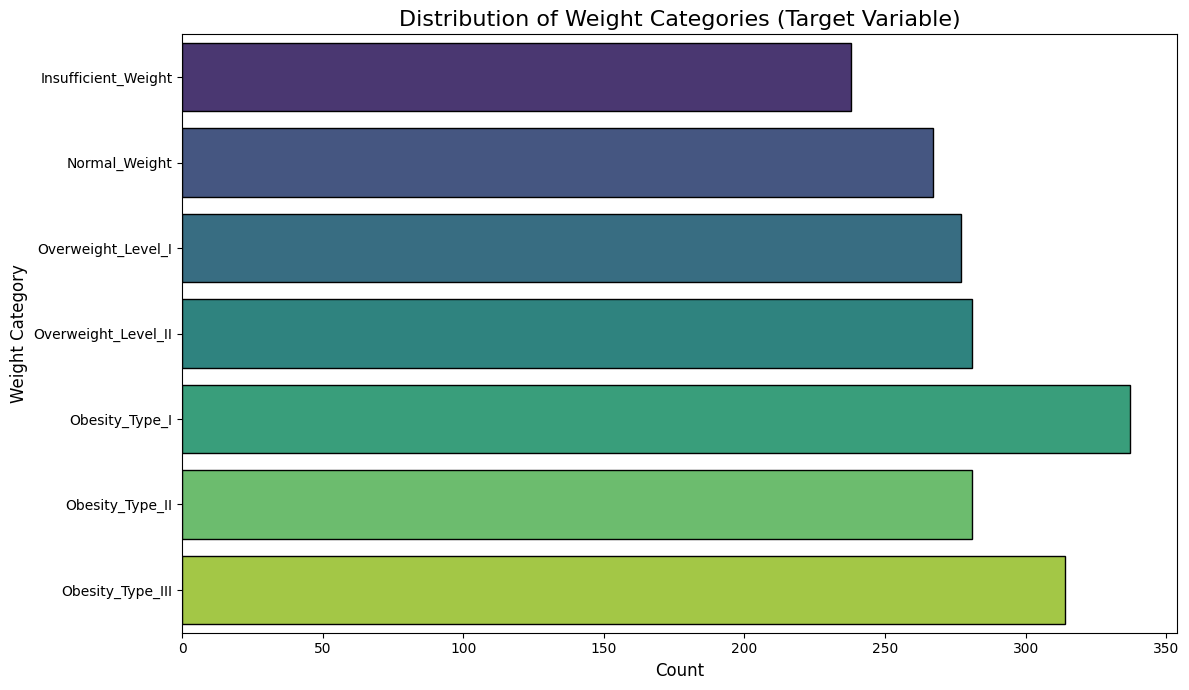


Target Class Counts:
Weight_Category
Obesity_Type_I         337
Obesity_Type_III       314
Overweight_Level_II    281
Obesity_Type_II        281
Overweight_Level_I     277
Normal_Weight          267
Insufficient_Weight    238
Name: count, dtype: int64

Target Class Percentages:
Weight_Category
Obesity_Type_I         16.89
Obesity_Type_III       15.74
Overweight_Level_II    14.09
Obesity_Type_II        14.09
Overweight_Level_I     13.88
Normal_Weight          13.38
Insufficient_Weight    11.93
Name: proportion, dtype: float64


In [9]:
# --- Step 6: Target Variable Analysis ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set the logical order for the weight categories
category_order = [
    'Insufficient_Weight', 
    'Normal_Weight', 
    'Overweight_Level_I', 
    'Overweight_Level_II', 
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III'
]

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.countplot(data=train_df, 
              y='Weight_Category', 
              order=category_order, 
              palette='viridis',
              edgecolor='black')

plt.title('Distribution of Weight Categories (Target Variable)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Weight Category', fontsize=12)
plt.tight_layout()
plt.show() 

# Print counts and percentages
print("\nTarget Class Counts:")
print(train_df['Weight_Category'].value_counts())
print("\nTarget Class Percentages:")
print((train_df['Weight_Category'].value_counts(normalize=True) * 100).round(2))

# Step 7: Feature-Target Relationships (Analysis Phase)

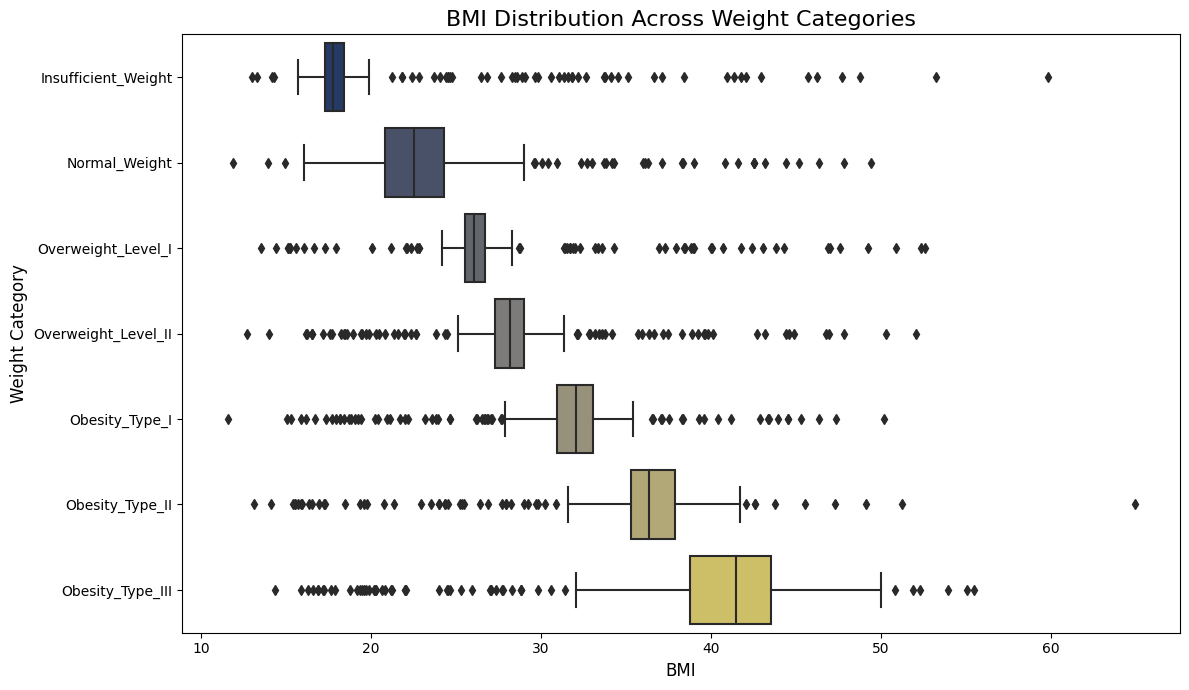

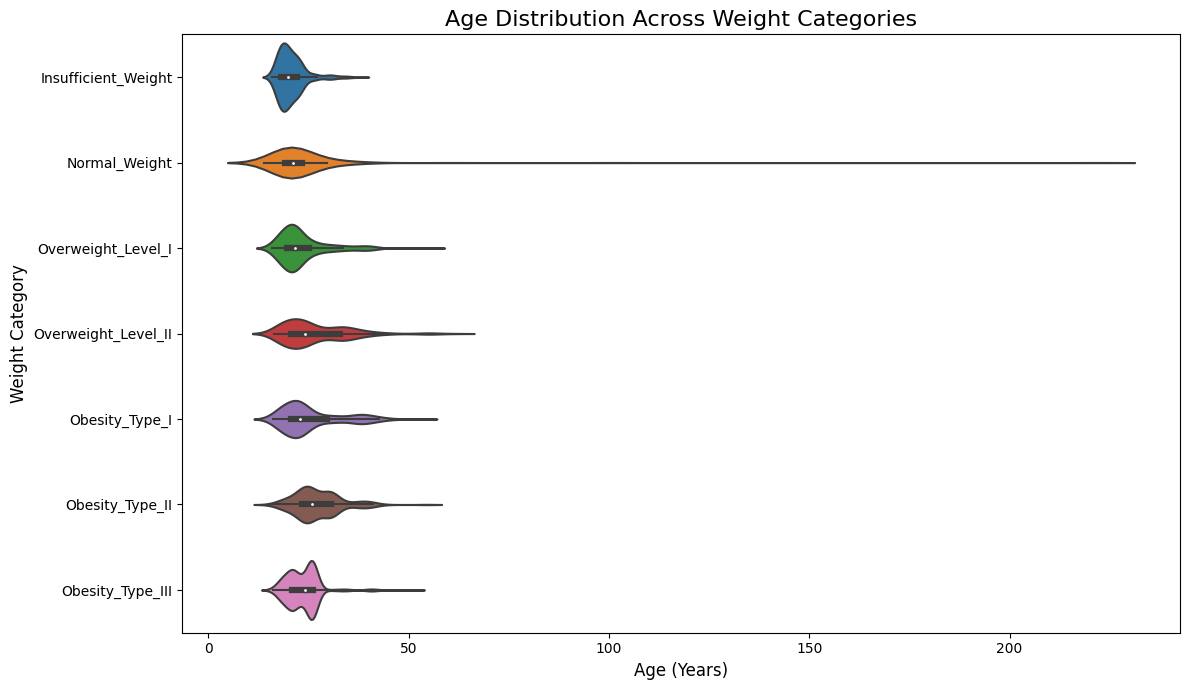

<Figure size 1000x600 with 0 Axes>

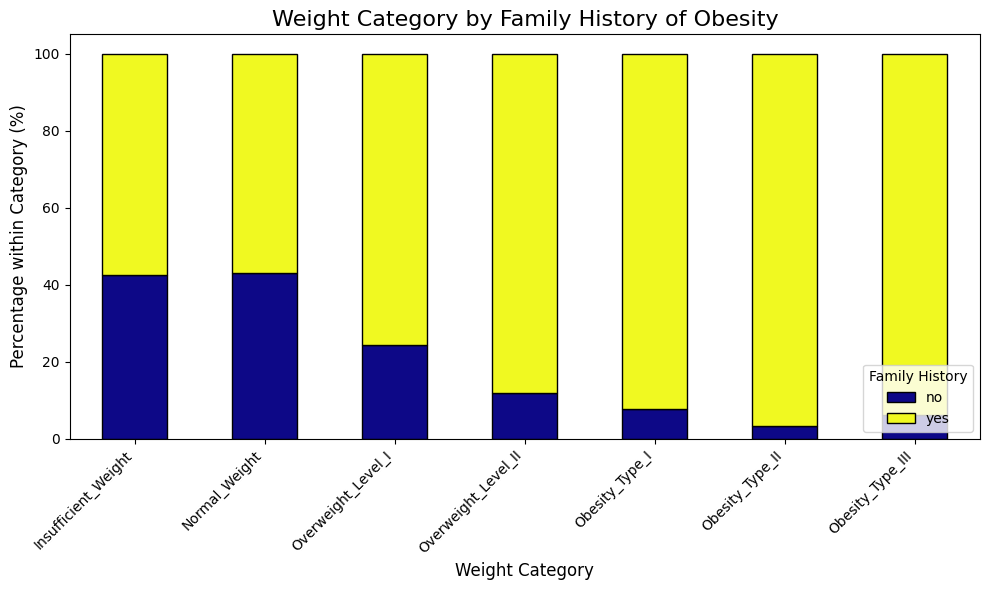

In [10]:
# --- Step 7: Feature-Target Relationships ---

# 7a. BMI vs. Weight Category (Crucial Plot)
plt.figure(figsize=(12, 7))
# Box plot shows the distribution (median, quartiles, outliers) of BMI for each category
sns.boxplot(data=train_df, x='BMI', y='Weight_Category', order=category_order, palette='cividis')
plt.title('BMI Distribution Across Weight Categories', fontsize=16)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Weight Category', fontsize=12)
plt.tight_layout()
plt.show()

# 7b. Numerical Feature Relationships (Example: Age)
plt.figure(figsize=(12, 7))
sns.violinplot(data=train_df, x='Age_Years', y='Weight_Category', order=category_order, palette='tab10')
plt.title('Age Distribution Across Weight Categories', fontsize=16)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Weight Category', fontsize=12)
plt.tight_layout()
plt.show()

# 7c. Categorical Feature Relationships (Example: Family History)
plt.figure(figsize=(10, 6))
family_hist_pivot = pd.crosstab(train_df['Weight_Category'], train_df['Family_History'], normalize='index') * 100

# Plot the stacked bar chart
family_hist_pivot.loc[category_order].plot(kind='bar', stacked=True, figsize=(10, 6), colormap='plasma', edgecolor='black')
plt.title('Weight Category by Family History of Obesity', fontsize=16)
plt.ylabel('Percentage within Category (%)', fontsize=12)
plt.xlabel('Weight Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Family History', loc='lower right')
plt.tight_layout()
plt.show()

Generating Box Plots for Numerical Features...


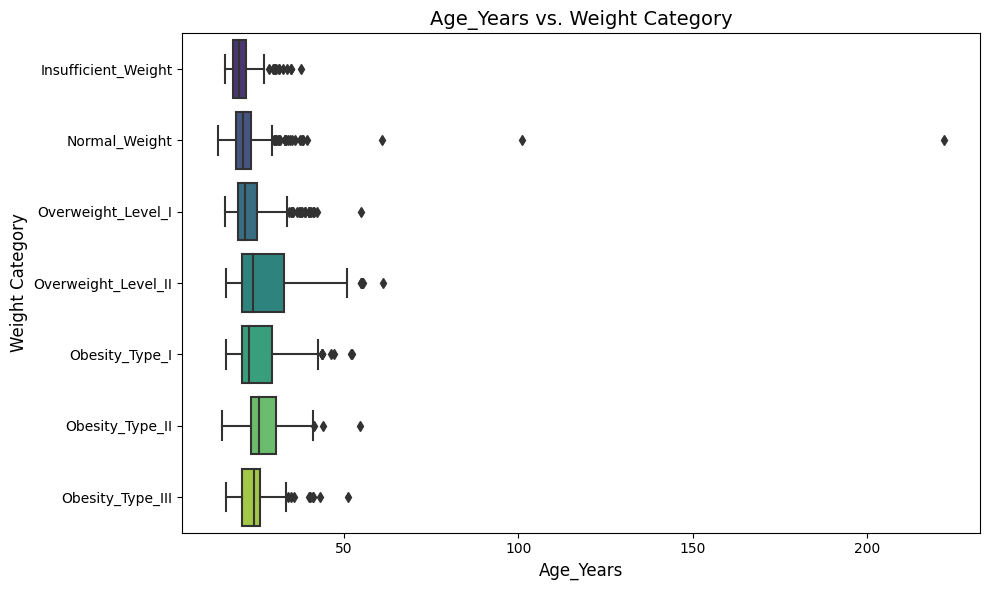

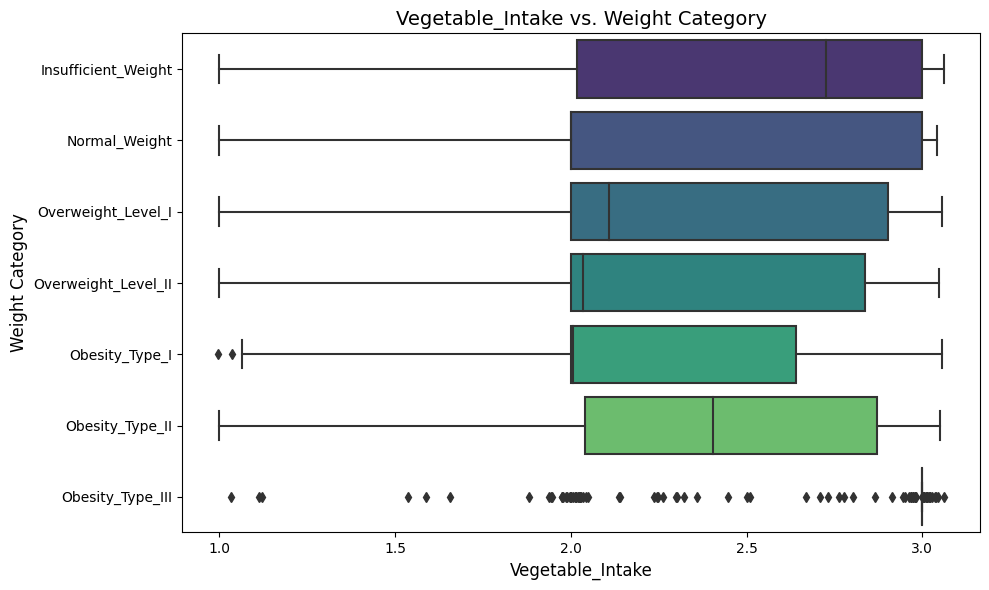

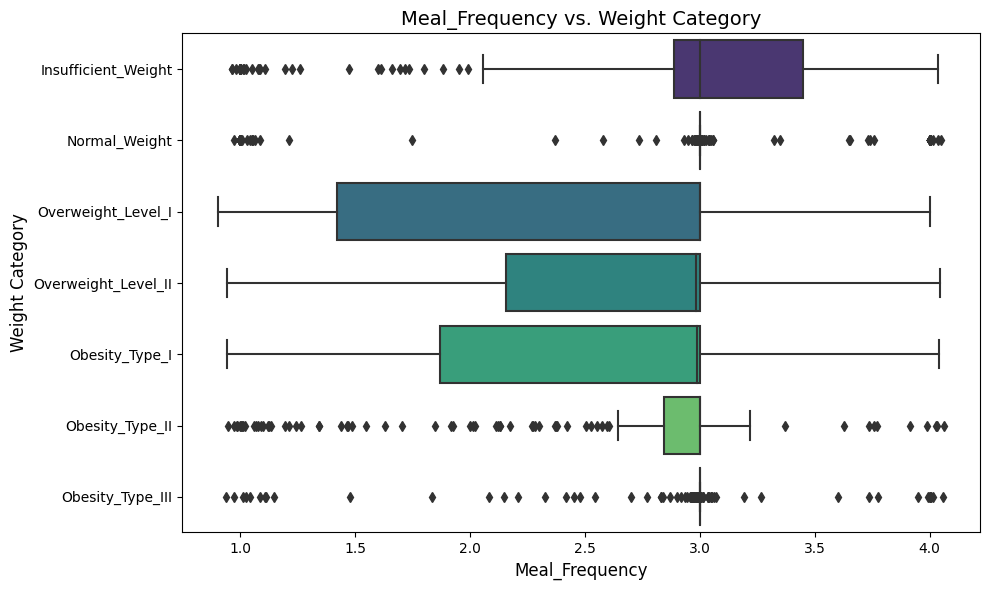

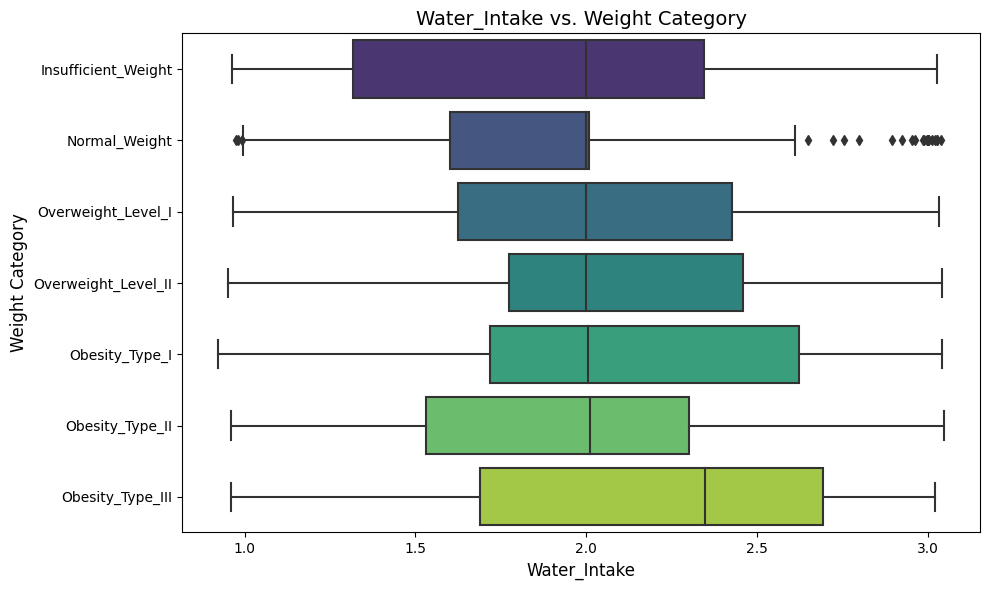

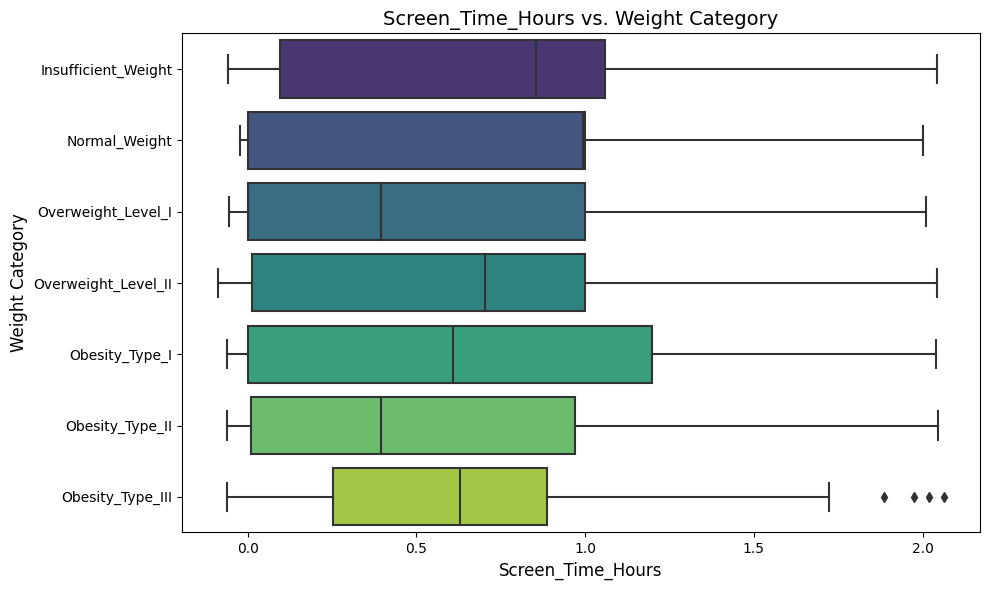

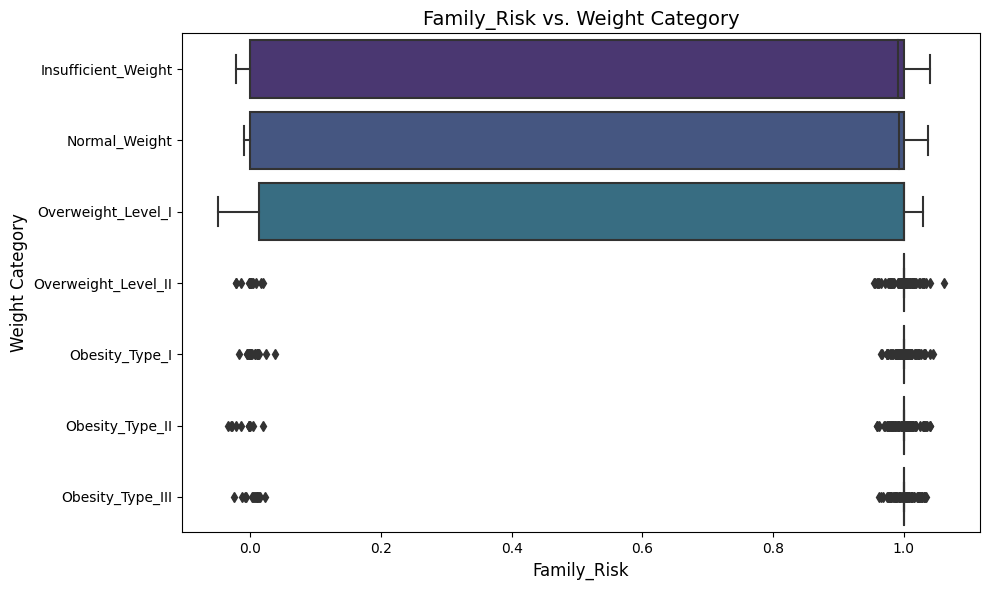

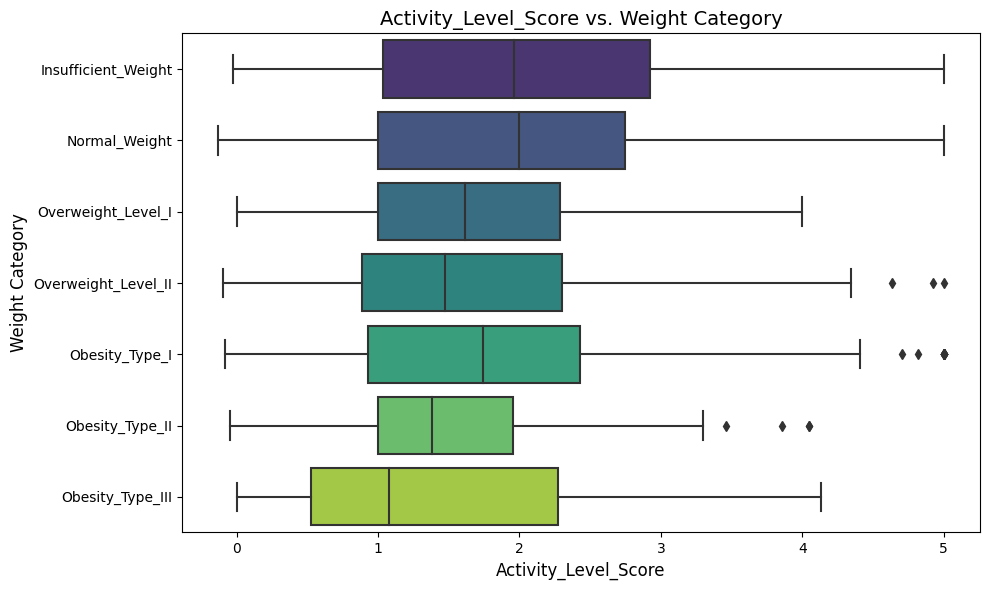

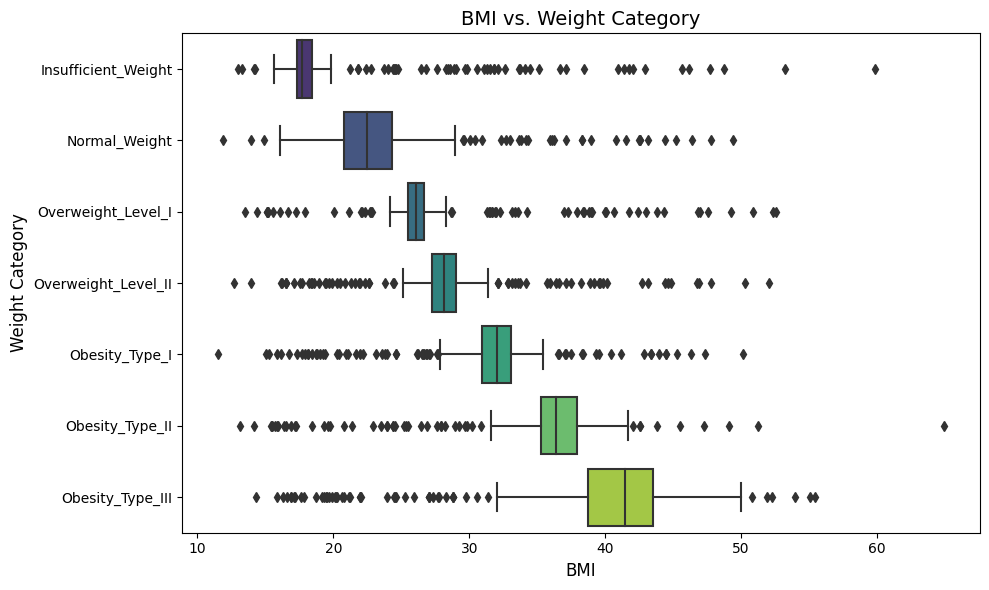


Generating Stacked Bar Charts for Categorical Features...


<Figure size 1000x600 with 0 Axes>

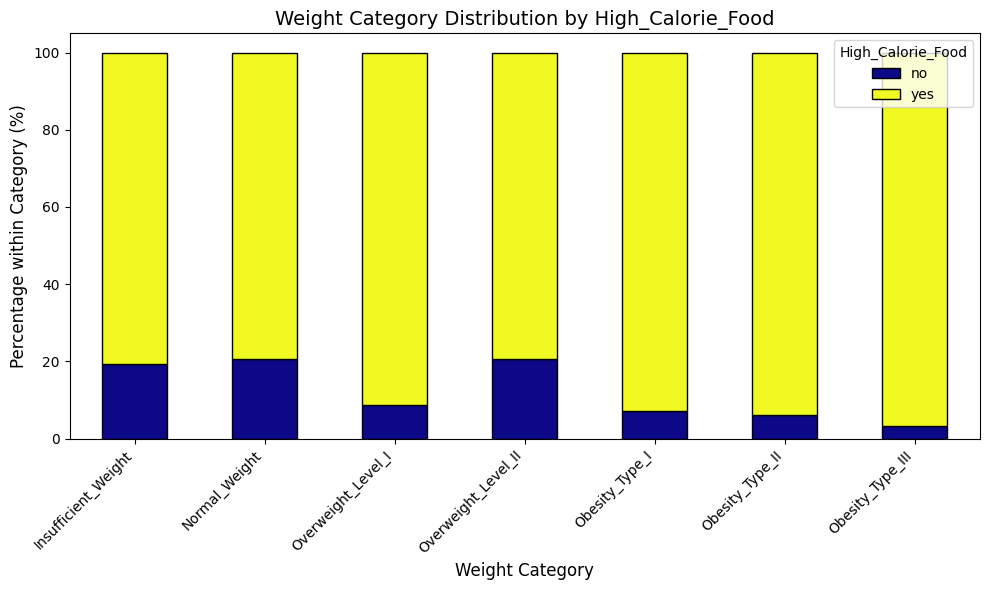

<Figure size 1000x600 with 0 Axes>

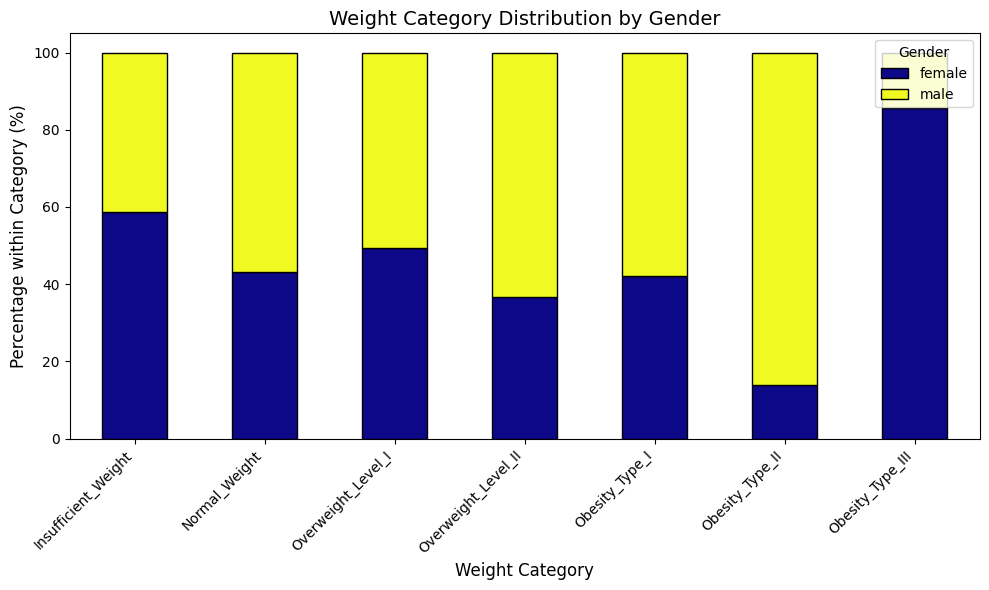

<Figure size 1000x600 with 0 Axes>

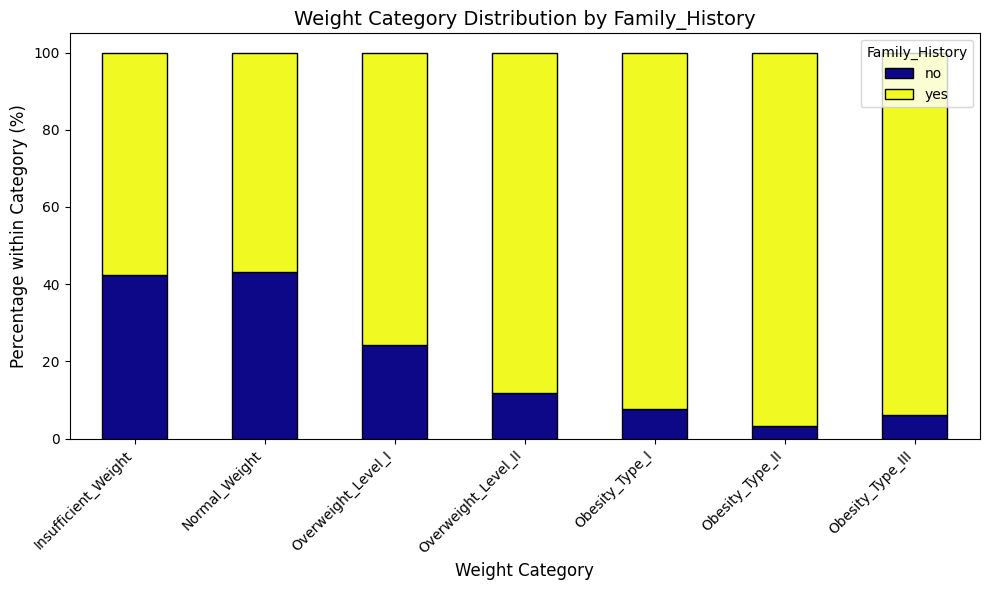

<Figure size 1000x600 with 0 Axes>

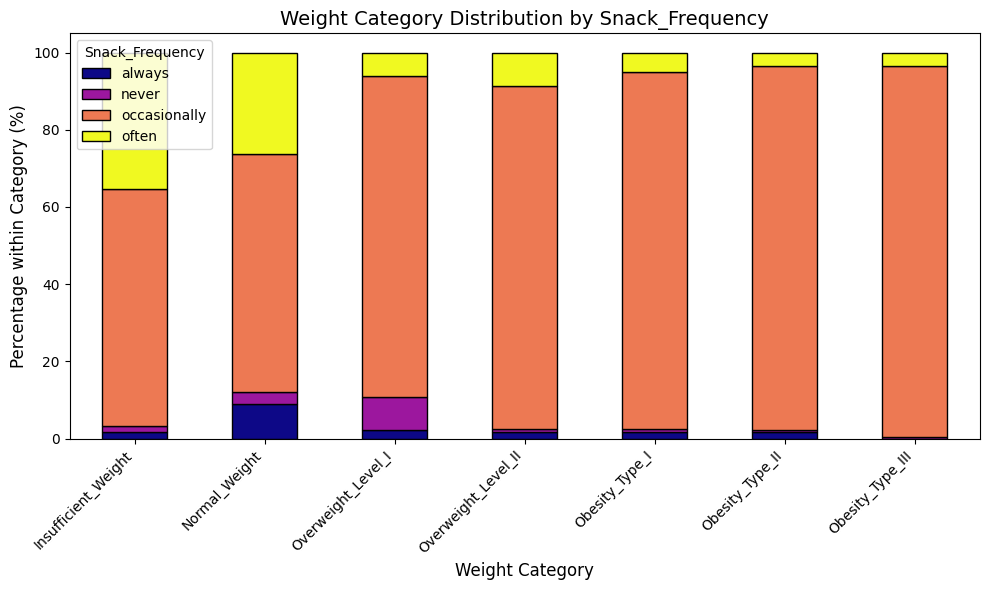

<Figure size 1000x600 with 0 Axes>

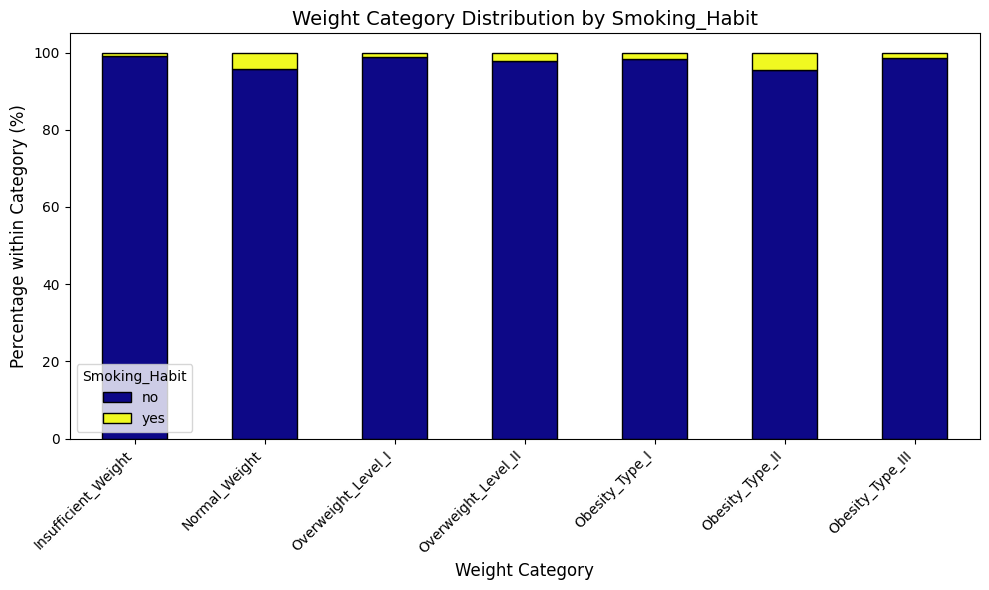

<Figure size 1000x600 with 0 Axes>

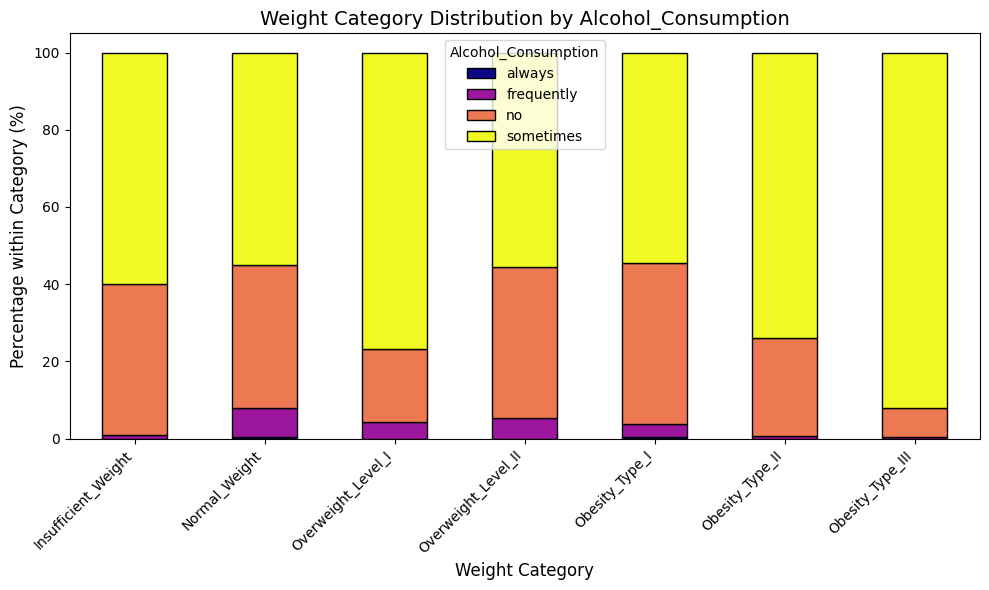

<Figure size 1000x600 with 0 Axes>

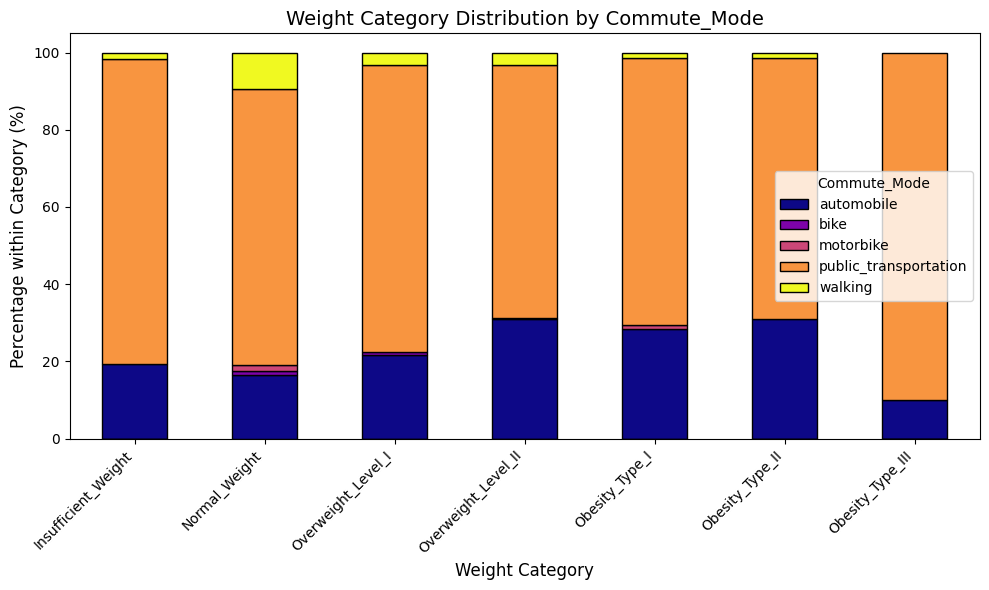

<Figure size 1000x600 with 0 Axes>

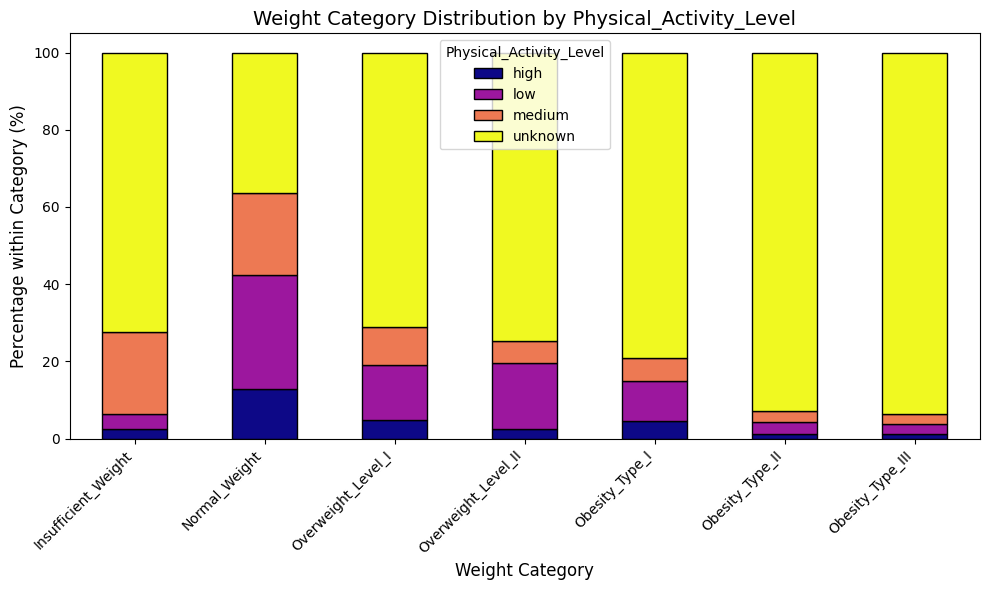

<Figure size 1000x600 with 0 Axes>

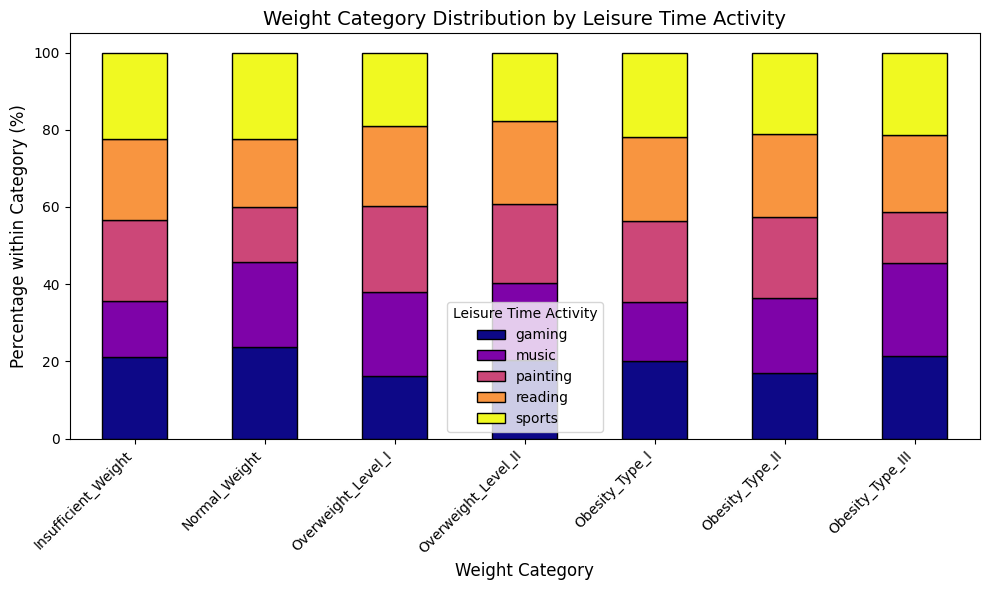

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the logical order for the target categories
category_order = [
    'Insufficient_Weight', 
    'Normal_Weight', 
    'Overweight_Level_I', 
    'Overweight_Level_II', 
    'Obesity_Type_I', 
    'Obesity_Type_II', 
    'Obesity_Type_III'
]

# --- Feature Lists ---

# Numerical features (including the engineered BMI)
numerical_cols = [
    'Age_Years', 'Vegetable_Intake', 'Meal_Frequency', 
    'Water_Intake', 'Screen_Time_Hours', 'Family_Risk', 
    'Activity_Level_Score', 'BMI'
]

# Categorical features (cleaned and imputed)
categorical_cols = [
    'High_Calorie_Food', 'Gender', 'Family_History', 'Snack_Frequency', 
    'Smoking_Habit', 'Alcohol_Consumption', 'Commute_Mode', 
    'Physical_Activity_Level', 'Leisure Time Activity'
]


# --- 1. Numerical Feature Analysis (Box Plots) ---
print("Generating Box Plots for Numerical Features...")
for i, col in enumerate(numerical_cols):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=train_df, x=col, y='Weight_Category', order=category_order, palette='viridis')
    plt.title(f'{col} vs. Weight Category', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Weight Category', fontsize=12)
    plt.tight_layout()
    plt.show()


# --- 2. Categorical Feature Analysis (Stacked Bar Charts) ---
print("\nGenerating Stacked Bar Charts for Categorical Features...")
for i, col in enumerate(categorical_cols):
    # Skip columns with too many unique values for a clean stacked bar (e.g., if there were many Leisure Time Activities)
    if train_df[col].nunique() > 10:
        print(f"Skipping stacked bar for {col}: too many unique values.")
        continue

    # Create a cross-tabulation table normalized by the index (Weight Category)
    pivot_table = pd.crosstab(train_df['Weight_Category'], train_df[col], normalize='index') * 100
    
    plt.figure(figsize=(10, 6))
    
    # Plot the stacked bar chart, ensuring category order is maintained
    # We use .loc[category_order] to select and order the rows
    pivot_table.loc[category_order].plot(kind='bar', stacked=True, figsize=(10, 6), colormap='plasma', edgecolor='black')
    
    plt.title(f'Weight Category Distribution by {col}', fontsize=14)
    plt.ylabel('Percentage within Category (%)', fontsize=12)
    plt.xlabel('Weight Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=col, loc='best')
    plt.tight_layout()
    plt.show()

# Step 8 - Preparing Data for Modeling

**8a. Split Data and Encode Target**

First, we separate the features and the target, and then we use an OrdinalEncoder to convert the string categories into numerical values (0 to 6), maintaining the crucial ordinal relationship.

In [12]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# 1. Define the Feature Matrix (X) and Target Vector (y)
# Drop the target variable from the training set to get X
X = train_df.drop(['Weight_Category', 'PersonID'], axis=1) 
y = train_df['Weight_Category']
X_test = test_df.drop('PersonID', axis=1).copy()  # Use a copy of the test set
PersonIDs = test_df['PersonID'].copy()

# 2. Define the exact order for the target variable
target_order = np.array([
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]).reshape(-1, 1)

# 3. Initialize and fit the Ordinal Encoder for the target
# We will use this encoder to transform 'y' now, and inverse_transform the predictions later.
target_encoder = OrdinalEncoder(categories=[target_order.flatten()])
y_encoded = target_encoder.fit_transform(y.values.reshape(-1, 1)).flatten()

print("Target variable encoded successfully.")

Target variable encoded successfully.


**8b. Define Preprocessing ColumnTransformer**

Next, we define the ColumnTransformer to apply the correct preprocessing (Scaling, Ordinal Encoding, One-Hot Encoding) to each column type simultaneously.

In [13]:
# Refinement: Cap extreme Age outliers
MAX_REASONABLE_AGE = 100 
train_df['Age_Years'].loc[train_df['Age_Years'] > MAX_REASONABLE_AGE] = MAX_REASONABLE_AGE
test_df['Age_Years'].loc[test_df['Age_Years'] > MAX_REASONABLE_AGE] = MAX_REASONABLE_AGE

/tmp/ipykernel_18/1435877116.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train_df['Age_Years'].loc[train_df['Age_Years'] > MAX_REASONABLE_AGE] = MAX_REASONABLE_AGE
/tmp/ipykernel_18/1435877116.py:3: SettingWithCopyWarning: 
A value i

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# --- Feature Lists (UPDATED) ---

# Numerical Features: Now includes the new Interaction feature
numerical_features = ['Age_Years', 'BMI', 'Vegetable_Intake', 'Meal_Frequency', 
                      'Water_Intake', 'Screen_Time_Hours', 'Family_Risk', 
                      'Activity_Level_Score', 'Sedentary_Diet_Risk', 'BMI_Sq'] # NEW!

# Ordinal Categorical Features: Now includes the new Age_Group feature
ordinal_features = ['Snack_Frequency', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Age_Group'] # NEW!

# Nominal Categorical Features: Unchanged
onehot_features = ['Gender', 'Family_History', 'High_Calorie_Food', 
                   'Smoking_Habit', 'Commute_Mode', 'Leisure Time Activity']

# --- Ordinal Category Definitions (UPDATED) ---
snack_order = ['never', 'occasionally', 'often', 'always']
alcohol_order = ['no', 'sometimes', 'frequently', 'always']
activity_order = ['unknown', 'low', 'medium', 'high']
# NEW: Define the exact order for the Age Groups
age_group_order = ['Child/Unknown', 'Teen', '20s', '30s', '40s', '50s', '60+']

# List of all category orders for the OrdinalEncoder
ordinal_categories = [snack_order, alcohol_order, activity_order, age_group_order]

# --- Create the Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_features),
        ('cat_ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features)
    ],
    remainder='drop'
)
print("Updated Preprocessor defined successfully with new features.")

Updated Preprocessor defined successfully with new features.


# Step 9: Train Initial Models (Baseline)

The goal of this step is to quickly get a sense of the potential accuracy using a powerful, out-of-the-box model like LightGBM (LGBM). By embedding the preprocessor inside a Pipeline, we ensure that scaling and encoding are applied correctly within each fold of the cross-validation process, preventing data leakage.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
import warnings

# Suppress warnings that might clutter the output
warnings.filterwarnings('ignore') 

# 1. Initialize the Classifier
# Use a strong classifier like LightGBM for a solid baseline
lgbm_model = LGBMClassifier(
    random_state=42, # For reproducibility
    device='gpu',   
    objective='multiclass', # Specify for 7 classes
    verbose=-1        # Suppress verbose output
)

# 2. Create the Full Pipeline
# This combines Step 8 (preprocessing) and the model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Your defined ColumnTransformer
    ('classifier', lgbm_model)
])

# 3. Perform Cross-Validation (CV)
# Use 5-fold CV to estimate the model's performance stability
# The scoring metric must be 'accuracy' as per the challenge evaluation
cv_scores = cross_val_score(
    full_pipeline, 
    X, 
    y_encoded, 
    cv=5, # 5-fold cross-validation
    scoring='accuracy'
)

# 4. Print Results
print("--- Baseline Model (LightGBM) Performance ---")
print(f"Individual CV Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


--- Baseline Model (LightGBM) Performance ---
Individual CV Scores: [0.7594 0.7519 0.787  0.7594 0.7419]
Mean CV Accuracy: 0.7599 ± 0.0150


# Step 10: Hyperparameter Tuning and Final Model Selection 

The next and final modeling step is to fine-tune the model to maximize the cross-validated accuracy score. We will use Grid Search to systematically test different combinations of hyperparameters for the LightGBM model.

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize the GPU Model (The fastest available option)
lgbm_model_gpu = LGBMClassifier(
    random_state=42, 
    device='gpu', # Use GPU acceleration
    objective='multiclass', 
    verbose=-1
)

# 2. Define the Full Pipeline with the new preprocessor
full_pipeline_gpu = Pipeline(steps=[
    ('preprocessor', preprocessor), # Uses your NEW preprocessor
    ('classifier', lgbm_model_gpu)
])

# 3. Initialize RandomizedSearchCV (CRITICAL: Fast Settings)
random_search_final = RandomizedSearchCV(
    full_pipeline_gpu, 
    param_distributions={
        'classifier__n_estimators': [300, 500],
        'classifier__learning_rate': [0.03, 0.07],
        'classifier__max_depth': [7, 12],
        'classifier__num_leaves': [50, 100], 
    },
    n_iter=10,      # Reduced iterations for speed
    cv=3,           # Reduced CV folds for speed
    scoring='accuracy', 
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the Search
print("\n--- Starting FINAL Randomized Search (Age & Interaction Features) ---")
# This should be your last, fastest, and best attempt.
random_search_final.fit(X, y_encoded) 

best_score_final = random_search_final.best_score_

print("\n--- FINAL FAST TRACK Tuning Results ---")
print(f"Best CV Accuracy Score (NEW FEATURES): {best_score_final:.4f}")


--- Starting FINAL Randomized Search (Age & Interaction Features) ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- FINAL FAST TRACK Tuning Results ---
Best CV Accuracy Score (NEW FEATURES): 0.7539


Step 12: Train and Combine XGBoost
You should run this immediately after your Randomized Search finished. We will add a similarly tuned XGBoost model to the final pipeline.

In [17]:
# --- Step 11: Final Training and Prediction ---

# 1. Retrieve the best model (using the result from the fast search)
final_model = random_search_final.best_estimator_

# 2. Predict on the test features (X_test)
y_pred_encoded = final_model.predict(X_test)

# 3. Inverse Transform back to string labels
y_pred_labels = target_encoder.inverse_transform(y_pred_encoded.reshape(-1, 1)).flatten()

# 4. Create Submission File (Using the previously loaded test_df)
submission_df = pd.DataFrame({
    'PersonID': test_df['PersonID'], 
    'Weight_Category': y_pred_labels
})

# 5. Save the file
submission_df.to_csv('submission.csv', index=False)

print("Final submission file 'submission.csv' created. Time to submit!")

Final submission file 'submission.csv' created. Time to submit!
